In [ ]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [1]:
# this could use some cleaning up

# MODEL PARAMETERS
grid_size_r, grid_size_z, grid_size_theta = 32, 32, 32 # eulerian grid size, 32 x 32 x 32
sim_prop = 1e-9 # percentage of particles to simulate
t_final = 100 # total duration of simulation
dt0 = 0.1 # seconds

# PHYSICAL CONSTANTS
kB = 1.3806503e-23 # boltzmann constant
q = 1.60217733e-19 # fundamental charge
eps0 = 8.85418782e-12 # epsilon0
mu0 = 1.256637061e-6 # mu0
mp, me = 2*1.672621925e-27, 9.1093837139e-31 # makes average 1

c = 1 / jnp.sqrt(mu0 * eps0)

# GEOMETRY AND STUFF
r_min, r_max = 0.8, 1.2
z_min, z_max = -0.2, 0.2

#Temperature, Magnetic, Num Particles, R0
R0 = (r_max - r_min) # characteristic length
clustering = 25.0 * R0 # how localized the normal distirbution is. earthbound music plays

N0 = 1e14 # number of particles in plasma
ionization = .50 # percentage of protons to electrons

B0 = 1 # background B field
T0 = 400000 # initial characteristic temperature

# DERIVED VALUES
N_e0 = (1 - ionization) * N0 # number of electrons
N_p0 = ionization * N0 # number of protons
N_e = int(N_e0 * sim_prop) # number of electrons to simulate
N_p = int(N_p0 * sim_prop) # number of protons to simulate

v0 = jnp.sqrt(2*kB*T0/(mp+me)) # characteristic velocity

# Charecteristic scales
t0 = R0 / v0 # characteristic timescale
E0 = v0 * B0 # characteristic E field
V0 = E0 * R0 # characteristic electric potential


V_dom = jnp.pi * (r_max**2 - r_min**2) * (z_max - z_min)

n0 = N0 / V_dom  # reference number density
rho0 = q * n0    # characteristic charge density

#
plasma_freq_p = jnp.sqrt(q**2 * n0 / (eps0 * mp))
plasma_freq_e = jnp.sqrt(q**2 * n0 / (eps0 * me))

# Omega = q * B / m, cyclotron frequency
gyro_freq_p = q * B0 / mp
gyro_freq_e = -q * B0 / me

print("Proton plasma frequency: ", plasma_freq_p)
print("Electron plasma frequency: ", plasma_freq_e)
print("Proton gyrofrequency: ", gyro_freq_p)
print("Electron gyrofrequency: ", gyro_freq_e)

seed = 42
key = jax.random.PRNGKey(seed)

NameError: name 'jnp' is not defined

\begin{equation*}
\frac{d\tilde{v}}{dt} = \frac{qE_0 t_0}{mv_0} \tilde{E} + \frac{qB_0 t_0}{m} (\tilde{v} \times \tilde{B}) = \frac{\lambda_D}{R_0} \tilde{E} + \frac{\Omega_c}{\omega_p} (\tilde{v} \times \tilde{B})
\end{equation*}
I will be nondimensionalizing with coefficients $\alpha_i = \frac{q_i E_0 t_0}{m_i v_0}$ and $\beta_i = \frac{q_i B_0 t_0}{m_i}$ personally to easily separate protons from electrons, but someone else can swap these out later pretty trivially

In [ ]:
x_p, x_e = jnp.empty(shape=(t_final,N_p,3)), jnp.empty(shape=(t_final,N_e,3)) #Store the 3 coordinates of each particle at each time step

v_p, v_e = jnp.empty_like(x_p), jnp.empty_like(x_e) #store the 3 velocity coordinates of each particle (N) at each time step (t_final)

#Number of particles max
N = max(N_p, N_e)

#Position sampling
while True:
    # random keys for r and z
    key, key_r, key_z = jax.random.split(key, 3)

    #Sample r, z
    r = jax.random.normal(key=key_r, shape=(N,2)) / clustering + (r_min + r_max) / (2*R0)
    z = jax.random.normal(key=key_z, shape=(N,2)) / clustering

    #ensure that r is inside the bounds we determined
    r_valid = jnp.all((r >= r_min / R0) & (r <= r_max / R0))
    z_valid = jnp.all((z >= z_min / R0) & (z <= z_max / R0))

    if r_valid and z_valid:
        break

#theta sampling
key, key_theta = jax.random.split(key, 2)
theta = jax.random.uniform(key=key_theta, shape=(N, 2)) * 2 * jnp.pi

#Set r, theta, z coordinates for proton
x_p = x_p.at[0,:,0].set(r[:N_p, 0])
x_p = x_p.at[0,:,1].set(theta[:N_p, 0])
x_p = x_p.at[0,:,2].set(z[:N_p, 0])

#set r, theta, z coordinates for electron
x_e = x_e.at[0,:,0].set(r[:N_e, 1])
x_e = x_e.at[0,:,1].set(theta[:N_e, 1])
x_e = x_e.at[0,:,2].set(z[:N_e, 1])


key, key_vr, key_vz, key_vtheta = jax.random.split(key, 4)

#std deviations for Gaussian velocity sampling
sigma = jnp.array([jnp.sqrt(kB*T0/mp), jnp.sqrt(kB*T0/me)]) / v0

vr = jax.random.normal(key=key_vr, shape=(N, 2)) * sigma
vz = jax.random.normal(key=key_vz, shape=(N, 2)) * sigma
vtheta = jax.random.normal(key=key_vtheta, shape=(N, 2)) * sigma #note that this is v_theta, not dtheta/dt

#Setting the velocities of all the particles
v_p = v_p.at[0,:,0].set(vr[:N_p, 0])
v_p = v_p.at[0,:,1].set(vtheta[:N_p, 0])
v_p = v_p.at[0,:,2].set(vz[:N_p, 0])

v_e = v_e.at[0,:,0].set(vr[:N_e, 1])
v_e = v_e.at[0,:,1].set(vtheta[:N_e, 1])
v_e = v_e.at[0,:,2].set(vz[:N_e, 1])

# VISUALIZATION
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')

x = r * jnp.cos(theta)
y = r * jnp.sin(theta)

ax.scatter(x[:N_p, 0], y[:N_p, 0], z[:N_p, 0], s=0.1, color='blue')
ax.scatter(x[:N_e, 1], y[:N_e, 1], z[:N_e, 1], s=0.1, color='orange')
ax.set_title("Initial position distribution")
plt.show()

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 2, 1, projection='3d')

vx = vr * jnp.cos(vtheta)
vy = vr * jnp.sin(vtheta)

ax.scatter(vx[:N_p, 0], vy[:N_p, 0], vz[:N_p, 0], s=0.1, color='blue')
ax.set_title("Initial deuteron velocity distribution")

ax = fig.add_subplot(1, 2, 2, projection='3d')
ax.scatter(vx[:N_e, 1], vy[:N_e, 1], vz[:N_e, 1], s=0.1, color='orange')
ax.set_title("Initial electron velocity distribution")
plt.show()

In [ ]:
alpha = jnp.array([q/mp, -q/me]) * E0 * t0 / v0
beta = jnp.array([q/mp, -q/me]) * B0 * t0

r_1D = jnp.linspace(r_min / R0, r_max / R0, grid_size_r + 1)
theta_1D = jnp.linspace(0, 2*jnp.pi, grid_size_theta + 1)
z_1D = jnp.linspace(z_min / R0, z_max / R0, grid_size_z + 1)

dr = r_1D[1] - r_1D[0]
dtheta = theta_1D[1] - theta_1D[0]
dz = z_1D[1] - z_1D[0]

r_grid = r_1D[0:-1] + dr / 2
theta_grid = theta_1D[0:-1] + dtheta / 2
z_grid = z_1D[0:-1] + dz / 2

volumes = 0.5 * jnp.diff(r_1D**2)[:, None, None] * jnp.diff(theta_1D)[None, :, None] * jnp.diff(z_1D)[None, None, :]

def compute_density(x: jnp.ndarray,
    qty=1, r_min=r_1D[0], r_max=r_1D[-1], z_min=z_1D[0], z_max=z_1D[-1], theta_min=0, theta_max=2*jnp.pi, volumes=volumes):

    r_idx = jnp.floor((x[:, 0] - r_min) / dr).astype(jnp.int32)
    theta_idx = jnp.floor((x[:, 1] - theta_min) / dtheta).astype(jnp.int32)
    z_idx = jnp.floor((x[:, 2] - z_min) / dz).astype(jnp.int32)

    r_idx = jnp.clip(r_idx, 0, grid_size_r)
    theta_idx = jnp.clip(theta_idx, 0, grid_size_theta)
    z_idx = jnp.clip(z_idx, 0, grid_size_z)

    flat_idx = r_idx * (grid_size_theta * grid_size_z) + theta_idx * grid_size_z + z_idx
    total_cells = grid_size_r * grid_size_theta * grid_size_z

    weights = jnp.broadcast_to(qty/sim_prop, (x.shape[0],)).ravel()
    cell_sums = jnp.bincount(flat_idx, weights=weights, length=total_cells)
    cell_sums = cell_sums.reshape(grid_size_r, grid_size_theta, grid_size_z)

    return jnp.where(volumes > 0, cell_sums / volumes, 0.0) # do i need to nondimensionalize?

\begin{equation*}
R_0^2 \nabla^2 \tilde{V} = - \sum_i \left(\frac{\omega_{p,i}}{\Omega_{c,i}}\right)^2 \tilde{\rho}_i
\end{equation*}

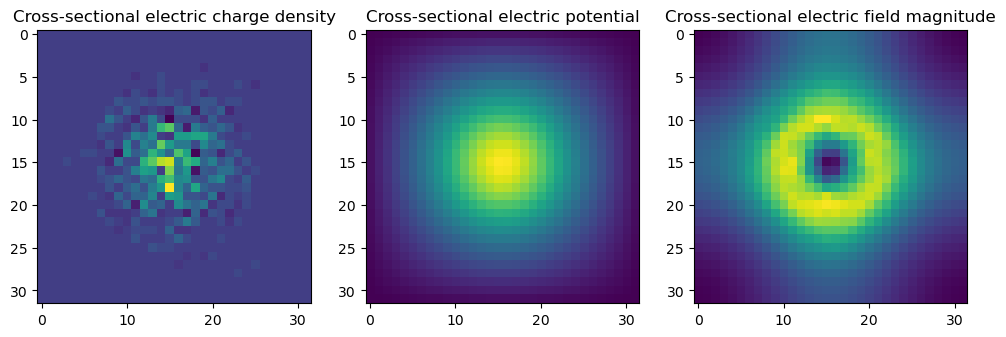

In [ ]:
# https://en.wikipedia.org/wiki/Conjugate_gradient_method
# good for solving this kind of linear system

def conjugate_gradient(A, b, x0, tol=1e-8, max_iter=1000):
    x = jnp.copy(x0)
    r = b - A(x)
    p = jnp.copy(r)
    last_res = jnp.vdot(r,r)

    for k in range(max_iter):
        Ap = A(p)
        pAp = jnp.vdot(p, Ap)

        alpha = jnp.where(pAp == 0.0, 0.0, last_res / pAp)
        x = x + alpha * p
        r = r - alpha * Ap
        res = jnp.vdot(r,r)

        if res < tol:
            break

        beta = res / last_res
        p = r + beta * p
        last_res = res

    return x

def laplacian(phi: jnp.ndarray):
    # finite difference slop
    phi_padded = jnp.pad(phi, ((1, 1), (0, 0), (1, 1)), constant_values=0.0)
    r_int = r_1D[0:-1] + dr/2

    phi_rp = phi_padded[2:,:,1:-1]
    phi_rm = phi_padded[:-2,:,1:-1]
    phi_rc = phi_padded[1:-1,:,1:-1]

    phi_tp = jnp.roll(phi, -1, axis=1)
    phi_tm = jnp.roll(phi, 1, axis=1)

    phi_zp = phi_padded[1:-1, :, 2:]
    phi_zm = phi_padded[1:-1, :, :-2]

    return ((phi_rp - 2.0 * phi_rc + phi_rm) / dr**2 + (phi_rp - phi_rm) / (2.0 * dr * r_int)
        + (phi_tp - 2.0 * phi_rc + phi_tm) / (dtheta**2 * r_grid**2) + (phi_zp - 2.0 * phi_rc + phi_zm) / dz**2)

def grad(phi: jnp.ndarray):
    # more finite difference slop
    phi_padded = jnp.pad(phi, ((1, 1), (0, 0), (1, 1)), constant_values=0.0)

    phi_rp = phi_padded[2:,:,1:-1]
    phi_rm = phi_padded[:-2,:,1:-1]
    grad_r = (phi_rp - phi_rm) / (2.0 * dr)

    phi_tp = jnp.roll(phi, -1, axis=1)
    phi_tm = jnp.roll(phi,  1, axis=1)
    grad_theta = (phi_tp - phi_tm) / (2.0 * dtheta * r_grid)

    phi_zp = phi_padded[1:-1,:,2:]
    phi_zm = phi_padded[1:-1,:,:-2]
    grad_z = (phi_zp - phi_zm) / (2.0 * dz)

    return jnp.array([grad_r, grad_theta, grad_z])

def curl(A_r, A_theta, A_z):
    # even more finite difference slop
    r = r_grid[:, None, None]

    Ar_pad = jnp.pad(A_r, ((1,1),(0,0),(1,1)), constant_values=0.0)
    Ath_pad = jnp.pad(A_theta, ((1,1),(0,0),(1,1)), constant_values=0.0)
    Az_pad = jnp.pad(A_z, ((1,1),(0,0),(1,1)), constant_values=0.0)

    dAz_dtheta = (jnp.roll(A_z, -1, axis=1) - jnp.roll(A_z, 1, axis=1)) / (2.0 * dtheta)
    dAth_dz = (Ath_pad[1:-1,:,2:] - Ath_pad[1:-1,:,:-2]) / (2.0 * dz)
    dAr_dz = (Ar_pad[1:-1, :, 2:] - Ar_pad[1:-1,:,:-2]) / (2.0 * dz)
    dAz_dr = (Az_pad[2:,:,1:-1] - Az_pad[:-2,:,1:-1]) / (2.0 * dr)
    dAth_dr = (Ath_pad[2:,:,1:-1] - Ath_pad[:-2,:,1:-1]) / (2.0 * dr)
    dAr_dtheta = (jnp.roll(A_r, -1, axis=1) - jnp.roll(A_r, 1, axis=1)) / (2.0 * dtheta)

    B_r = dAz_dtheta / r - dAth_dz
    B_theta = dAr_dz - dAz_dr
    B_z = dAth_dr + A_theta / r - dAr_dtheta / r

    return B_r, B_theta, B_z

def solve_poisson(f, tol=1e-16, max_iter=1000):
    A_op = lambda phi: -laplacian(phi)
    b_vec = -f

    x0 = jnp.zeros_like(f)

    return conjugate_gradient(A_op, b_vec, x0, tol=tol, max_iter=max_iter)

# i don't feel super good about how i nondimensionalized this, so someone please check it
# in particular, not sure whether i should multiply/divide the laplacian by the R_0^2 that came out during nondimensionalization

poisson_sol_coef_p = -(plasma_freq_p / gyro_freq_p)**2
poisson_sol_coef_e = -(plasma_freq_e / gyro_freq_e)**2
poisson_sol = (poisson_sol_coef_p * compute_density(x_p[0,:,:], q) + poisson_sol_coef_e * compute_density(x_e[0,:,:], -q)) / (rho0)

fig, ax = plt.subplots(1,3, figsize=(12,12))
ax[0].imshow((compute_density(x_p[0,:,:], q) + compute_density(x_e[0,:,:], -q))[:,0,:])
ax[0].set_title("Cross-sectional electric charge density")

V = solve_poisson(poisson_sol)
ax[1].imshow(V[:,0,:])
ax[1].set_title("Cross-sectional electric potential")

E = grad(V)

ax[2].imshow((E[0]**2 + E[1]**2 + E[2]**2)[:,0,:])
ax[2].set_title("Cross-sectional electric field magnitude")
plt.show()

In [ ]:
# also worth checking, the B field is way stronger than i would expect even though im p sure i nondimensionalized everything correctly
# there might be missing R_0 and R_0^2 terms again...

mag_poisson_coef_p = poisson_sol_coef_p * (v0 / c) ** 2
mag_poisson_coef_e = poisson_sol_coef_e * (v0 / c) ** 2

def laplacian_r_component(phi):
    r = r_grid[:, None, None]
    return laplacian(phi) - phi / r**2

def laplacian_theta_component(phi):
    r = r_grid[:, None, None]
    return laplacian(phi) - phi / r**2

def solve_poisson_r(f, tol=1e-16, max_iter=1000):
    A_op = lambda phi: -laplacian_r_component(phi)
    return conjugate_gradient(A_op, -f, jnp.zeros_like(f), tol=tol, max_iter=max_iter)

def solve_poisson_theta(f, tol=1e-16, max_iter=1000):
    A_op = lambda phi: -laplacian_theta_component(phi)
    return conjugate_gradient(A_op, -f, jnp.zeros_like(f), tol=tol, max_iter=max_iter)

t_idx = 0

J_r = (mag_poisson_coef_p * compute_density(x_p[0,:,:], qty=v_p[0,:,0]) + mag_poisson_coef_e * compute_density(x_e[0,:,:], qty=v_e[0,:,0])) / rho0
J_theta = (mag_poisson_coef_p * compute_density(x_p[0,:,:], qty=v_p[0,:,1]) + mag_poisson_coef_e * compute_density(x_e[0,:,:], qty=v_e[0,:,1])) / rho0
J_z = (mag_poisson_coef_p * compute_density(x_p[0,:,:], qty=v_p[0,:,2]) + mag_poisson_coef_e * compute_density(x_e[0,:,:], qty=v_e[0,:,2])) / rho0

A_r = solve_poisson_r(J_r)
A_theta = solve_poisson_theta(J_theta)
A_z = solve_poisson(J_z)

B_r, B_theta, B_z = curl(A_r, A_theta, A_z)
# add background B field here, i'm gonna call it a night